In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import json, os, kagglehub, cv2, tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from matplotlib.patches import Rectangle
from tqdm import tqdm
!pip install ultralytics
import ultralytics



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 84.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


2. Data

Original Width: 5832 | Cropped Width: 2041
Saved cropped image as 'port_area_cropped.jpg'


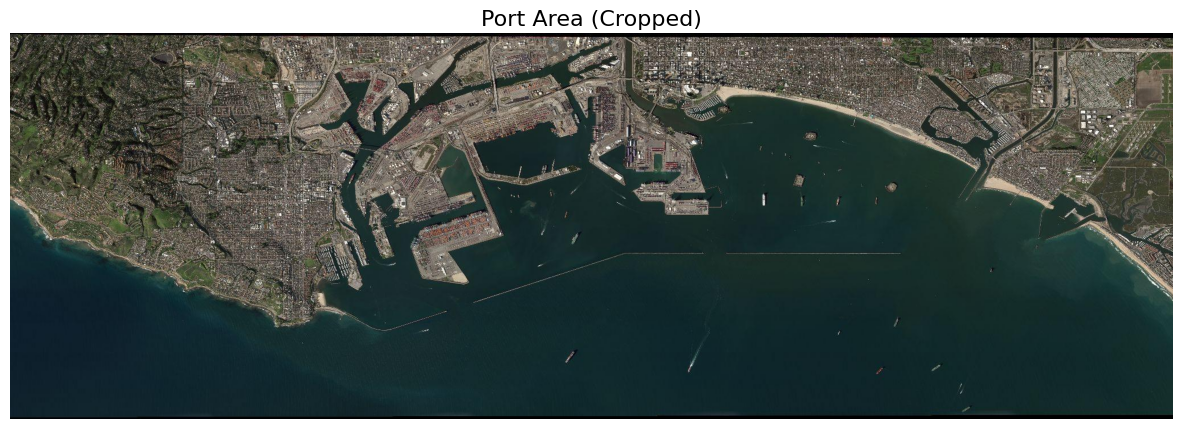

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import os

# ── 1. Load image ──────────────────────────────────────────────────
image_path = '/content/drive/MyDrive/Me  Cho tôi/Career  Sự Nghiệp/Research/Supply Chain/Josh/Data/LAPort-3PM-2Feb26.jpg'

# Verify file exists
if not os.path.exists(image_path):
    print(f"❌ Error: Image file not found at {image_path}")
else:
    # Load original image
    image_bgr = cv2.imread(image_path)
    image_full = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    h_orig, w_orig = image_full.shape[:2]

    # ── 2. CROP TO PORT AREA ────────────────────────────────────────
    x_start = int(w_orig * 0.25)
    x_end = int(w_orig * 0.60)

    image = image_full[:, x_start:x_end]
    print(f"Original Width: {w_orig} | Cropped Width: {image.shape[1]}")

    # ── 3. Scale image (optional) ───────────────────────────────────
    scale_factor = 1
    image = cv2.resize(image, None, fx=scale_factor, fy=scale_factor,
                       interpolation=cv2.INTER_CUBIC)

    # ── 4. Save the cropped image ───────────────────────────────────
    output_bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    cv2.imwrite('port_area_cropped.jpg', output_bgr)
    print("Saved cropped image as 'port_area_cropped.jpg'")

    # ── 5. Display ──────────────────────────────────────────────────
    plt.figure(figsize=(15, 10))
    plt.imshow(image)
    plt.title("Port Area (Cropped)", fontsize=16)
    plt.axis("off")
    plt.show()

Model Training

In [ ]:
import numpy as np
import json
import os
import cv2
import kagglehub
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from sklearn.model_selection import train_test_split

# ── 1. DATA LOADING ────────────────────────────────────────────────────────
path = kagglehub.dataset_download("rhammell/ships-in-satellite-imagery")
with open(os.path.join(path, "shipsnet.json")) as f:
    dataset = json.load(f)

X = np.array(dataset["data"], dtype="float32").reshape(-1, 3, 80, 80).transpose(0, 2, 3, 1) / 255.0
y = np.array(dataset["labels"], dtype="int")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Class weights to handle ShipsNet's ~3:1 non-ship:ship imbalance.
# Without this, the model can hit 75% accuracy by predicting "no ship" always.
neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)
class_weight = {0: 1.0, 1: neg / pos}
print(f"Class weight for ships: {class_weight[1]:.2f}  (neg={neg}, pos={pos})")

# ── 2. AUGMENTATION PIPELINE ───────────────────────────────────────────────
# Kept outside the model so it only fires during .fit(), not predict().
# RandomRotation is important — ships appear at arbitrary angles overhead.
augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.5),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
], name="augmentation")

# ── 3. MODEL ───────────────────────────────────────────────────────────────
# FIX: EfficientNetB0 instead of V2B3.
# V2B3 applies 3 strided downsamples in its stem, reducing 80px patches to
# ~10px feature maps before any real extraction. B0 handles small inputs cleanly.
def build_ship_net(trainable_base: bool = False) -> Model:
    base = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=(80, 80, 3),
    )
    base.trainable = trainable_base

    inputs = layers.Input(shape=(80, 80, 3))
    x = base(inputs, training=trainable_base)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="swish")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs)
    return model

# ── 4. STAGE 1 — TRAIN HEAD ONLY ──────────────────────────────────────────
# FIX: Freeze the base first. The head needs to stabilise before we allow
# the pretrained weights to shift — otherwise the backbone degrades before
# the classifier knows what it's doing.
print("\nStage 1: Training classification head (base frozen)...")
model = build_ship_net(trainable_base=False)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

# Apply augmentation to training data before fitting
X_train_aug = augment(X_train, training=True).numpy()

model.fit(
    X_train_aug, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    class_weight=class_weight,
)

# ── 5. STAGE 2 — FINE-TUNE FULL NETWORK ───────────────────────────────────
# FIX: Unfreeze base only after head has converged, and at 10x lower LR.
print("\nStage 2: Fine-tuning full network (base unfrozen at 1e-5)...")
model = build_ship_net(trainable_base=True)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.fit(
    X_train_aug, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    class_weight=class_weight,
)

print("\nTest set evaluation:")
model.evaluate(X_test, y_test)

# ── 6. HARD NEGATIVE MINING ────────────────────────────────────────────────
def mine_hard_negatives(
    model: Model,
    image_path: str,
    patch_size: int = 80,
    stride: int = 40,
    top_k: int = 200,
) -> np.ndarray:
    """
    Scans a port scene, collects all sliding-window patches, runs batched
    inference, and returns the top-k highest-confidence false positives
    (land/dock regions the model mistakes for ships).

    FIX 1: Batched predict() instead of per-patch loop — orders of magnitude
    faster. A 2000x2000 scene at stride=40 is ~2000 patches; the old loop
    re-dispatched to the GPU each iteration.

    FIX 2: top_k instead of a fixed threshold. A hardcoded 0.8 cutoff can
    return anywhere from 5 to 5000 negatives depending on the scene.
    Top-k gives controlled, reproducible class balance.
    """
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Could not read image at: {image_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype("float32") / 255.0
    h, w, _ = img.shape

    patches, coords = [], []
    for y_pos in range(0, h - patch_size, stride):
        for x_pos in range(0, w - patch_size, stride):
            patches.append(img[y_pos:y_pos + patch_size, x_pos:x_pos + patch_size])
            coords.append((y_pos, x_pos))

    patches = np.array(patches, dtype="float32")
    print(f"  Running batched inference on {len(patches)} patches...")
    preds = model.predict(patches, batch_size=64, verbose=0).flatten()

    # Return top-k most confident predictions as hard negatives.
    # These are patches the model is most wrong about — highest training signal.
    top_indices = np.argsort(preds)[-top_k:]
    hard_negatives = patches[top_indices]
    print(f"  Selected top {len(hard_negatives)} hard negatives "
          f"(confidence range: {preds[top_indices].min():.2f}–{preds[top_indices].max():.2f})")
    return hard_negatives

# ── 7. STAGE 3 — RE-TRAIN WITH HARD NEGATIVES ─────────────────────────────
la_port_image = "/content/port_area_cropped.jpg"

if os.path.exists(la_port_image):
    print(f"\nMining hard negatives from: {la_port_image}")
    new_negatives = mine_hard_negatives(model, la_port_image, top_k=200)

    # Sanity check: don't let negatives swamp the positive examples
    n_pos = int(np.sum(y_train == 1))
    if len(new_negatives) > n_pos * 2:
        print(f"  Warning: {len(new_negatives)} negatives vs {n_pos} positives — "
              f"consider reducing top_k to avoid class collapse.")

    X_train_ext = np.concatenate([X_train, new_negatives])
    y_train_ext = np.concatenate([y_train, np.zeros(len(new_negatives), dtype="int")])

    # Recompute class weights for the extended set
    neg_ext = int(np.sum(y_train_ext == 0))
    pos_ext = int(np.sum(y_train_ext == 1))
    class_weight_ext = {0: 1.0, 1: neg_ext / pos_ext}

    print("\nStage 3: Fine-tuning to suppress land false positives...")
    model.optimizer.learning_rate = 1e-6
    model.fit(
        X_train_ext, y_train_ext,
        epochs=5,
        batch_size=16,
        class_weight=class_weight_ext,
    )

    print("\nFinal test set evaluation after hard negative mining:")
    model.evaluate(X_test, y_test)
else:
    print(f"\nSkipping hard negative mining — image not found at: {la_port_image}")

# ── 8. SAVE ────────────────────────────────────────────────────────────────
model.save("ship_detector_fixed.keras")
print("\nSaved: ship_detector_fixed.keras")

Water Mask


In [ ]:
import numpy as np
import cv2

def build_water_mask(image_bgr, debug=False):
    h, w = image_bgr.shape[:2]
    b = image_bgr[:,:,0].astype("float32")
    g = image_bgr[:,:,1].astype("float32")
    r = image_bgr[:,:,2].astype("float32")
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV).astype("float32")
    hue, sat, val = hsv[:,:,0], hsv[:,:,1], hsv[:,:,2]

    blue_dom  = ((b - r) > 3) & ((b - g) > -5)
    gray      = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY).astype("float32")
    k         = np.ones((9,9), dtype="float32") / 81.0
    mean      = cv2.filter2D(gray, -1, k)
    mean_sq   = cv2.filter2D(gray**2, -1, k)
    local_std = np.sqrt(np.maximum(0, mean_sq - mean**2))
    low_tex   = local_std < 15.0
    hsv_water = ((hue>=60)&(hue<=160)&(val>=40)&(val<=210)&(sat<140))
    raw       = blue_dom & low_tex & hsv_water

    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(21,21))
    k_open  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(9,9))
    m = cv2.morphologyEx(raw.astype("uint8"), cv2.MORPH_CLOSE, k_close)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, k_open)

    min_area = int(0.005 * h * w)
    n, labels, stats, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    out = np.zeros_like(m)
    for i in range(1, n):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            out[labels==i] = 1

    if debug:
        print(f"  blue_dom={blue_dom.mean():.1%}  low_tex={low_tex.mean():.1%}  "
              f"hsv_water={hsv_water.mean():.1%}  combined={raw.mean():.1%}  "
              f"after_morph={out.mean():.1%}")
    return out.astype(bool)

# ── now call it ──
img  = cv2.imread("/content/port_area_cropped.jpg")
mask = build_water_mask(img, debug=True)

overlay = img.copy()
overlay[mask] = (overlay[mask] * 0.5 + np.array([120,60,0]) * 0.5).astype("uint8")
cv2.imwrite("water_mask_preview.jpg", overlay)
print(f"Coverage: {mask.mean():.1%}")

  blue_dom=47.9%  low_tex=54.5%  hsv_water=22.0%  combined=12.2%  after_morph=16.4%
Coverage: 16.4%


Testing


  blue_dom=47.9%  low_tex=54.5%  hsv_water=22.0%  combined=12.2%  after_morph=16.4%
Full image water coverage: 16.4%
ROI size: 2856x2708  |  Water coverage in ROI: 26.7%
Patches: 5532 water  |  12816 land skipped  |  18348 total
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 351ms/step
Detections before NMS: 77  |  after NMS: 39


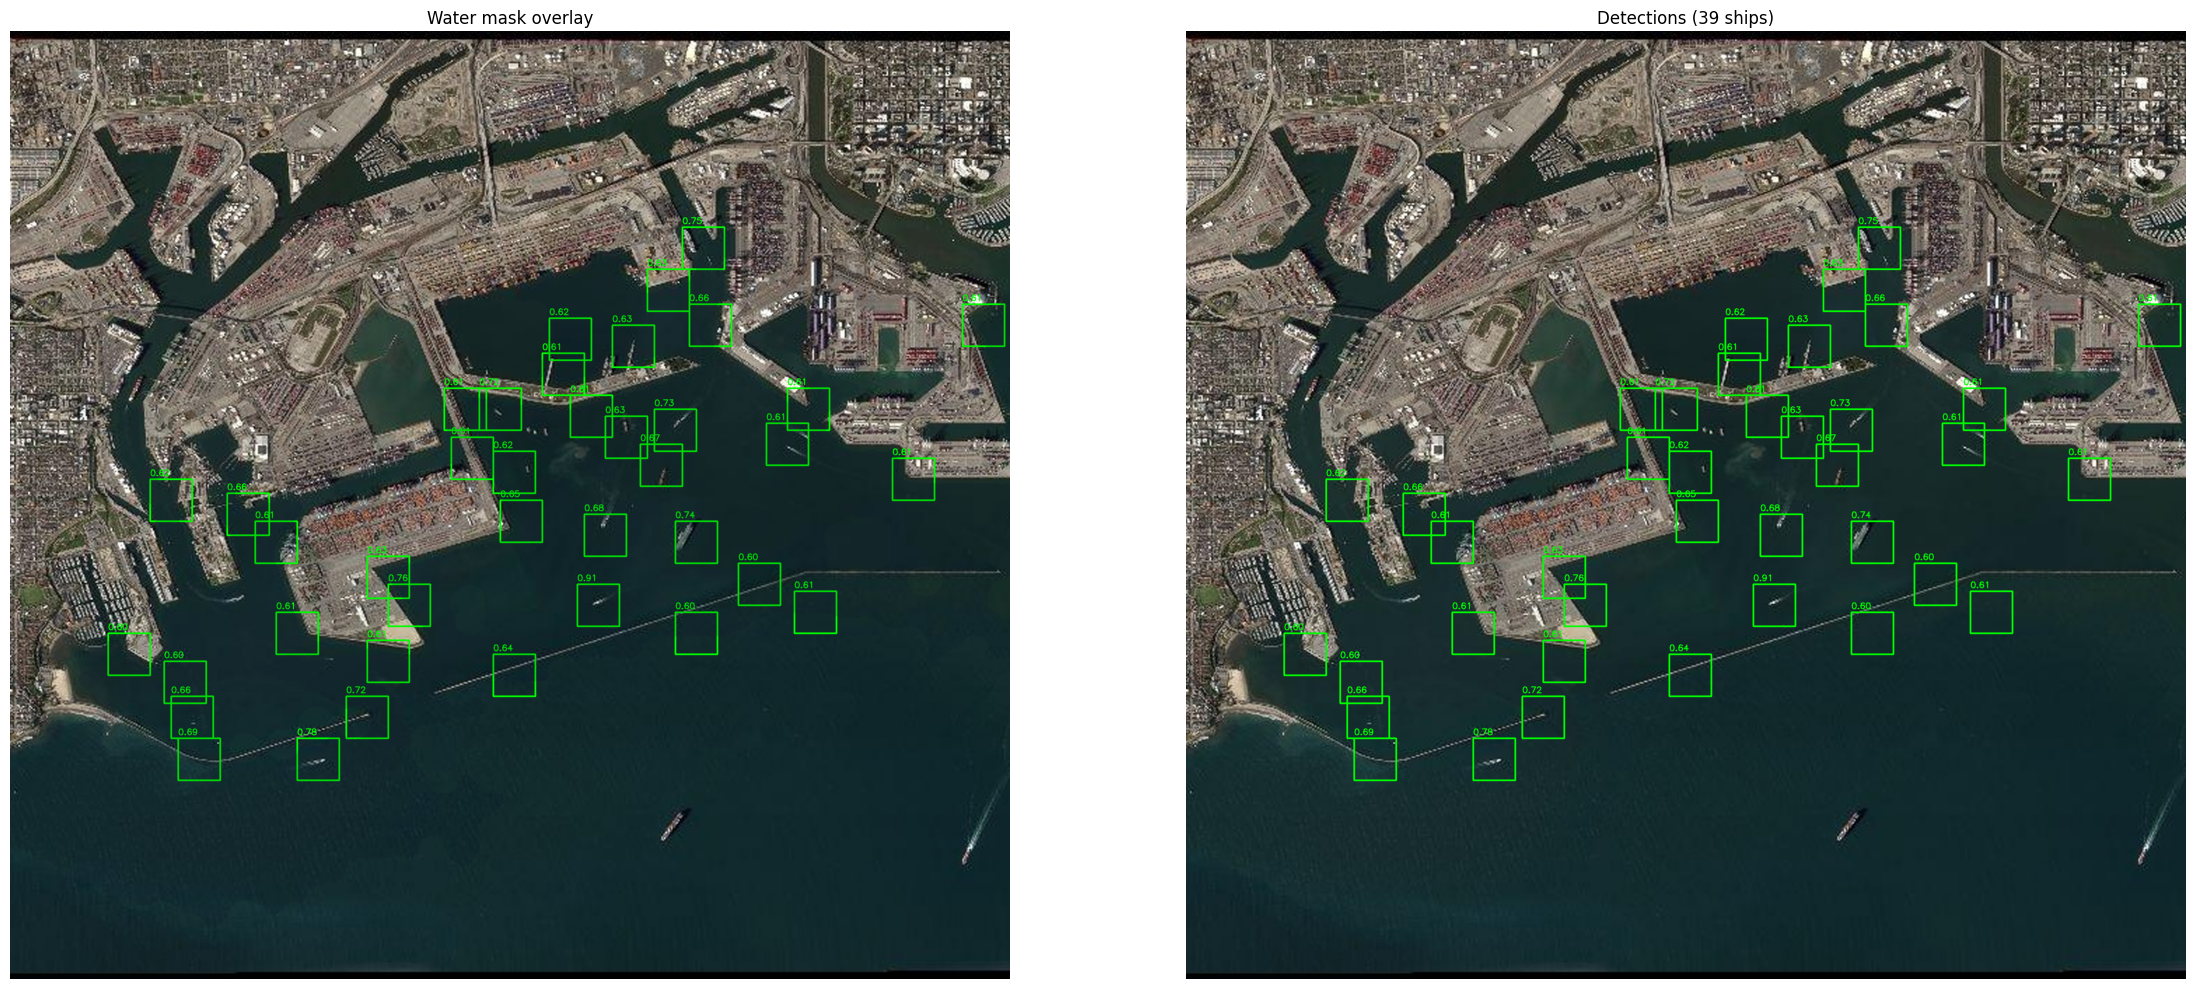

In [ ]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from matplotlib import pyplot as plt

# ── 1. Setup ───────────────────────────────────────────────────────────────
model = load_model('/content/ship_detector_fixed.keras')

#model= load_model('/content/ship_detector_v2.keras')
scale_factor     = 4
patch_size       = 80
stride           = 20
threshold        = 0.6
visual_multiplier = 1.5
water_threshold  = 0.35   # patch must be ≥35% water to be considered

# ── 2. Load image + build water mask on the ORIGINAL image ─────────────────
# Key fix: load the original image, not the tinted preview.
# The preview has blue tinting baked in which will shift pixel values and
# confuse both the water mask and the model.
image_path = '/content/port_area_cropped.jpg'
#image_path = '/content/water_mask_preview.jpg'
image_bgr  = cv2.imread(image_path)
image_rgb  = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
h_orig, w_orig = image_rgb.shape[:2]

# Build water mask on the full original image (native resolution)
water_mask_full = build_water_mask(image_bgr, debug=True)
print(f"Full image water coverage: {water_mask_full.mean():.1%}")

# ── 3. Crop ROI from both image and mask ───────────────────────────────────
x_start = int(w_orig * 0.25)
x_end   = int(w_orig * 0.60)

roi_rgb  = image_rgb[:, x_start:x_end]
roi_mask = water_mask_full[:, x_start:x_end]   # ← same crop on the mask

# ── 4. Scale both ROI and mask together ────────────────────────────────────
roi_scaled = cv2.resize(
    roi_rgb, None,
    fx=scale_factor, fy=scale_factor,
    interpolation=cv2.INTER_CUBIC
)
# Use INTER_NEAREST for the mask — it's binary, interpolation would corrupt it
mask_scaled = cv2.resize(
    roi_mask.astype("uint8"), None,
    fx=scale_factor, fy=scale_factor,
    interpolation=cv2.INTER_NEAREST
).astype(bool)

h, w = roi_scaled.shape[:2]
print(f"ROI size: {w}x{h}  |  Water coverage in ROI: {mask_scaled.mean():.1%}")

# ── 5. Extract patches — skip land patches via mask ────────────────────────
patches, coords = [], []
skipped_land = 0

for y in range(0, h - patch_size + 1, stride):
    for x in range(0, w - patch_size + 1, stride):
        # Check what fraction of this patch is water
        patch_mask = mask_scaled[y:y+patch_size, x:x+patch_size]
        water_frac = patch_mask.mean()

        if water_frac < water_threshold:
            skipped_land += 1
            continue  # land patch — skip entirely, don't even run model

        patch = roi_scaled[y:y+patch_size, x:x+patch_size].astype("float32") / 255.0
        patches.append(patch)
        coords.append((x, y))

total = ((h - patch_size) // stride + 1) * ((w - patch_size) // stride + 1)
print(f"Patches: {len(patches)} water  |  {skipped_land} land skipped  |  {total} total")

# ── 6. Batched inference ────────────────────────────────────────────────────
patches_arr = np.array(patches, dtype="float32")
with tf.device('/GPU:0'):
    preds = model.predict(patches_arr, batch_size=256, verbose=1).flatten()

# ── 7. NMS ─────────────────────────────────────────────────────────────────
def nms(boxes, iou_threshold=0.15):
    if not boxes:
        return []
    boxes = sorted(boxes, key=lambda b: b[4], reverse=True)
    kept  = []
    while boxes:
        best = boxes.pop(0)
        kept.append(best)
        def iou(a, b):
            ix1 = max(a[0], b[0]); iy1 = max(a[1], b[1])
            ix2 = min(a[2], b[2]); iy2 = min(a[3], b[3])
            inter = max(0, ix2-ix1) * max(0, iy2-iy1)
            union = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
            return inter / union if union > 0 else 0
        boxes = [b for b in boxes if iou(best, b) < iou_threshold]
    return kept

boxes = []
for (x, y), conf in zip(coords, preds):
    if conf > threshold:
        cx, cy       = x + patch_size // 2, y + patch_size // 2
        half         = int((patch_size * visual_multiplier) // 2)
        x1, y1       = max(0, cx - half), max(0, cy - half)
        x2, y2       = min(w, cx + half), min(h, cy + half)
        boxes.append([x1, y1, x2, y2, float(conf)])

final_boxes = nms(boxes)
print(f"Detections before NMS: {len(boxes)}  |  after NMS: {len(final_boxes)}")

# ── 8. Draw & show ─────────────────────────────────────────────────────────
output = cv2.cvtColor(roi_scaled, cv2.COLOR_RGB2BGR)
for (x1, y1, x2, y2, conf) in final_boxes:
    cv2.rectangle(output, (x1, y1), (x2, y2), (0, 255, 0), 3)
    cv2.putText(output, f"{conf:.2f}", (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

# Also draw the water mask as a faint blue tint so you can verify alignment
mask_vis = mask_scaled.copy().astype("uint8")
tint = output.copy()
tint[mask_scaled] = (tint[mask_scaled] * 0.85 + np.array([40, 20, 0]) * 0.15).astype("uint8")

fig, axes = plt.subplots(1, 2, figsize=(24, 10))
axes[0].imshow(cv2.cvtColor(tint,   cv2.COLOR_BGR2RGB)); axes[0].set_title("Water mask overlay"); axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB)); axes[1].set_title(f"Detections ({len(final_boxes)} ships)"); axes[1].axis("off")
plt.tight_layout()
plt.show()

Running predictions on test set...

Confusion matrix at default threshold (0.5)
              precision    recall  f1-score   support

     No Ship      0.980     0.903     0.940       600
        Ship      0.765     0.945     0.846       200

    accuracy                          0.914       800
   macro avg      0.873     0.924     0.893       800
weighted avg      0.926     0.914     0.917       800


Confusion matrix at recall-tuned threshold (0.238)
              precision    recall  f1-score   support

     No Ship      1.000     0.360     0.529       600
        Ship      0.342     1.000     0.510       200

    accuracy                          0.520       800
   macro avg      0.671     0.680     0.520       800
weighted avg      0.836     0.520     0.525       800



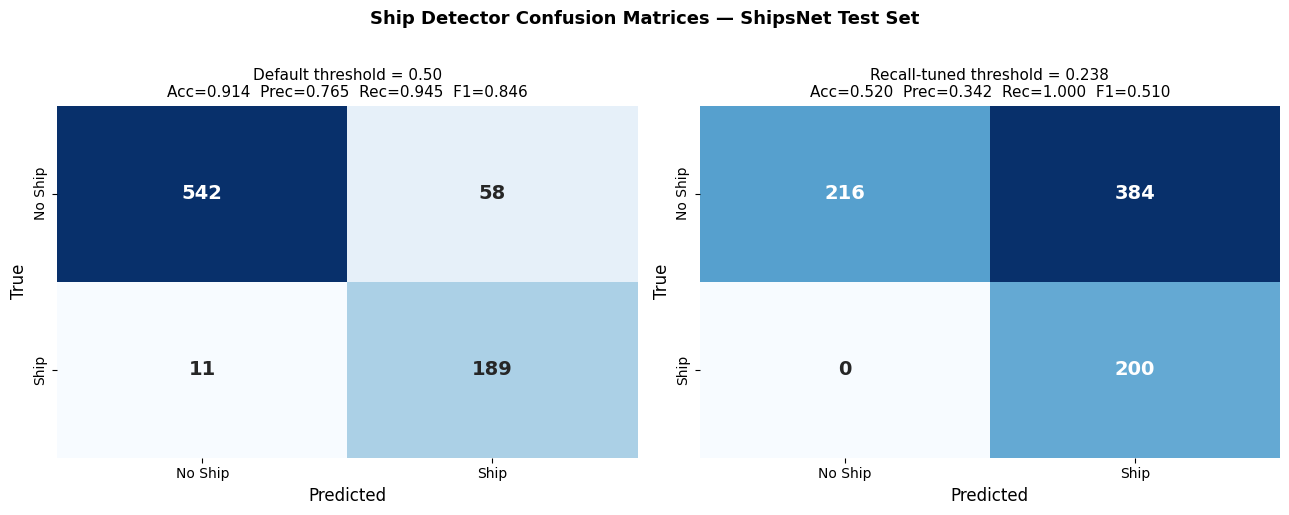


Saved: confusion_matrix.png


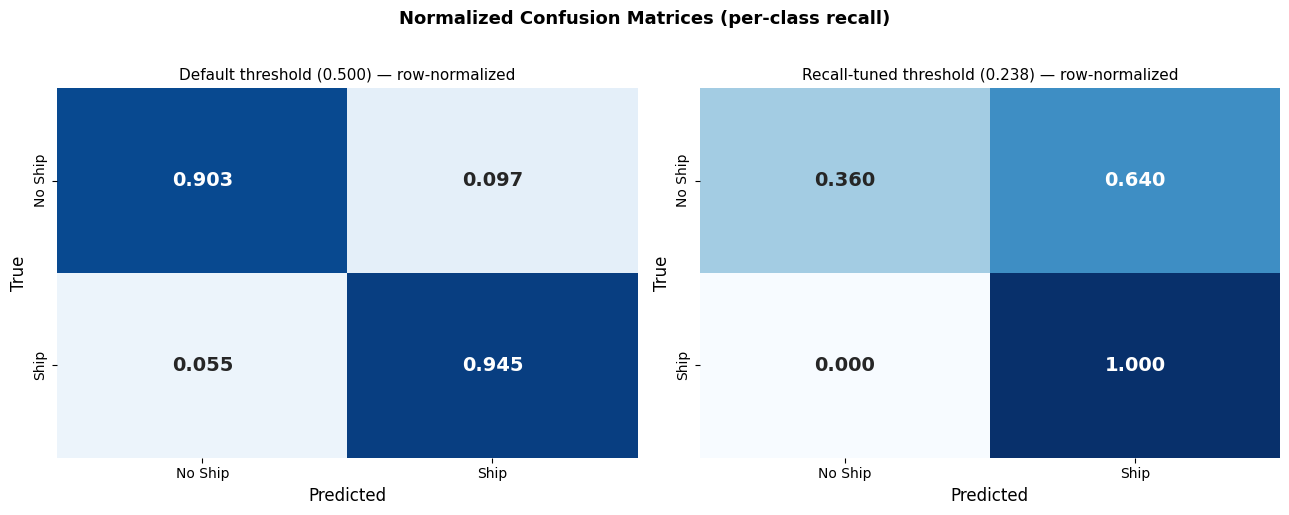

Saved: confusion_matrix_normalized.png

Summary
Metric          Default (0.50)     Tuned (0.238)     
------------------------------------------------------------
accuracy        0.914              0.520             
precision       0.765              0.342             
recall          0.945              1.000             
f1              0.846              0.510             
------------------------------------------------------------
TP              189                200               
FP              58                 384               
FN              11                 0                 
TN              542                216               


In [ ]:
"""
Confusion matrix evaluation for the ship detector.

Drop into Colab after training completes. Generates:
  1. Confusion matrix at default threshold (0.5)
  2. Confusion matrix at recall-tuned threshold
  3. Side-by-side comparison plot
  4. Classification report with precision/recall/F1 per class

Assumes you have in scope:
  - model (trained Keras model)
  - X_test, y_test (held-out arrays)
  - best_threshold (from tune_threshold(), optional)
"""

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)


# ── 1. PREDICT ON TEST SET ─────────────────────────────────────────────────
print("Running predictions on test set...")
y_proba = model.predict(X_test, batch_size=64, verbose=0).flatten()


# ── 2. CONFUSION MATRIX HELPER ─────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, threshold, ax=None, title=None):
    """Plot a single confusion matrix with annotated cells."""
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Compute derived rates
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["No Ship", "Ship"],
        yticklabels=["No Ship", "Ship"],
        cbar=False, ax=ax,
        annot_kws={"size": 14, "weight": "bold"},
    )
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("True", fontsize=12)

    title_text = title or f"Threshold = {threshold:.2f}"
    subtitle = (f"Acc={accuracy:.3f}  Prec={precision:.3f}  "
                f"Rec={recall:.3f}  F1={f1:.3f}")
    ax.set_title(f"{title_text}\n{subtitle}", fontsize=11)

    return {
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "precision": float(precision), "recall": float(recall),
        "f1": float(f1), "accuracy": float(accuracy)
    }


# ── 3. EVALUATE AT DEFAULT (0.5) THRESHOLD ─────────────────────────────────
threshold_default = 0.5
y_pred_default = (y_proba >= threshold_default).astype(int)

print(f"\n{'=' * 60}")
print(f"Confusion matrix at default threshold ({threshold_default})")
print(f"{'=' * 60}")
print(classification_report(
    y_test, y_pred_default,
    target_names=["No Ship", "Ship"],
    digits=3
))


# ── 4. EVALUATE AT RECALL-TUNED THRESHOLD ──────────────────────────────────
# Use best_threshold if you ran tune_threshold(); else fall back
try:
    threshold_tuned = best_threshold
except NameError:
    print("\nNo `best_threshold` in scope — computing one for 95% recall...")
    from sklearn.metrics import precision_recall_curve
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    valid_idx = np.where(recalls[:-1] >= 0.95)[0]
    threshold_tuned = float(thresholds[valid_idx[-1]]) if len(valid_idx) else 0.3

y_pred_tuned = (y_proba >= threshold_tuned).astype(int)

print(f"\n{'=' * 60}")
print(f"Confusion matrix at recall-tuned threshold ({threshold_tuned:.3f})")
print(f"{'=' * 60}")
print(classification_report(
    y_test, y_pred_tuned,
    target_names=["No Ship", "Ship"],
    digits=3
))


# ── 5. SIDE-BY-SIDE PLOT ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

stats_default = plot_confusion_matrix(
    y_test, y_pred_default, threshold_default,
    ax=axes[0], title=f"Default threshold = {threshold_default:.2f}"
)
stats_tuned = plot_confusion_matrix(
    y_test, y_pred_tuned, threshold_tuned,
    ax=axes[1], title=f"Recall-tuned threshold = {threshold_tuned:.3f}"
)

plt.suptitle("Ship Detector Confusion Matrices — ShipsNet Test Set",
             fontsize=13, weight="bold", y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()
print("\nSaved: confusion_matrix.png")


# ── 6. NORMALIZED CONFUSION MATRIX (for the paper) ─────────────────────────
# Row-normalized: each row sums to 1.0 (per-class recall view)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (y_pred, thresh, label) in zip(
    axes,
    [(y_pred_default, threshold_default, "Default"),
     (y_pred_tuned, threshold_tuned, "Recall-tuned")]
):
    cm = confusion_matrix(y_test, y_pred, normalize="true")
    sns.heatmap(
        cm, annot=True, fmt=".3f", cmap="Blues",
        xticklabels=["No Ship", "Ship"],
        yticklabels=["No Ship", "Ship"],
        cbar=False, ax=ax, vmin=0, vmax=1,
        annot_kws={"size": 14, "weight": "bold"}
    )
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("True", fontsize=12)
    ax.set_title(f"{label} threshold ({thresh:.3f}) — row-normalized", fontsize=11)

plt.suptitle("Normalized Confusion Matrices (per-class recall)",
             fontsize=13, weight="bold", y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrix_normalized.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix_normalized.png")


# ── 7. SUMMARY TABLE ───────────────────────────────────────────────────────
print(f"\n{'=' * 60}")
print("Summary")
print(f"{'=' * 60}")
print(f"{'Metric':<15} {'Default (0.50)':<18} {'Tuned ({:.3f})'.format(threshold_tuned):<18}")
print("-" * 60)
for key in ["accuracy", "precision", "recall", "f1"]:
    print(f"{key:<15} {stats_default[key]:<18.3f} {stats_tuned[key]:<18.3f}")
print("-" * 60)
print(f"{'TP':<15} {stats_default['tp']:<18} {stats_tuned['tp']:<18}")
print(f"{'FP':<15} {stats_default['fp']:<18} {stats_tuned['fp']:<18}")
print(f"{'FN':<15} {stats_default['fn']:<18} {stats_tuned['fn']:<18}")
print(f"{'TN':<15} {stats_default['tn']:<18} {stats_tuned['tn']:<18}")